# 1. Imports and Configuration
Here we load the necessary libraries and define our global configuration variables.

In [ ]:
import zipfile
import os

# Path to your zip file (Update this if you used Google Drive)
# If you used Method A (Direct Upload), it's just '/content/data.zip'
zip_path = '/content/data.zip'

# Unzip it
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Files unzipped!")

Files unzipped!


In [ ]:
import os
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

# Configuration
img_rows, img_cols = 224, 224
num_classes = 3
batch_size = 32
epochs = 35

# TODO: UPDATE THESE PATHS TO YOUR LOCAL DIRECTORIES
train_data_dir = "/content/dataset/data/train"
validation_data_dir = "/content/dataset/data/val"

# 2. Data Preparation
We use ImageDataGenerator to load images from the directory and apply data augmentation (rotation, shifts, flips) to the training set to prevent overfitting.

In [ ]:
# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling only for validation
validation_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 28709 images belonging to 3 classes.
Found 7178 images belonging to 3 classes.


# 3. Model Architecture
We will load the MobileNet model pre-trained on ImageNet (excluding the top layers) and add our own custom Fully Connected (Dense) layers for emotion classification.

In [ ]:
# Load MobileNet Base
mobile_net = MobileNet(weights='imagenet',
                       include_top=False,
                       input_shape=(img_rows, img_cols, 3))

# Define the Custom Head (Top Model)
def add_top_model(bottom_model, num_classes):
    """Creates the top or head of the model that will be
    placed on top of the bottom layers"""

    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)

    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(512, activation='relu')(top_model)

    top_model = Dense(num_classes, activation='softmax')(top_model)

    return top_model

# Assemble the model
FC_Head = add_top_model(mobile_net, num_classes)
model = Model(inputs=mobile_net.input, outputs=FC_Head)

print(model.summary())

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,854,403 (22.33 MB)

 Trainable params: 5,832,515 (22.25 MB)

 Non-trainable params: 21,888 (85.50 KB)

None


# 4. Layer Freezing/Unfreezing
Here we decide which layers to train. In your original script, you set everything to True.

Note: In Transfer Learning, it is often better to freeze the base layers first, train the head, and then unfreeze layers for fine-tuning. Currently, the code below unfreezes all layers.

In [ ]:
# Lock or Unlock layers for training
for layer in mobile_net.layers:
    layer.trainable = True

# Print layer status (Optional: Comment out if output is too long)
for (i, layer) in enumerate(mobile_net.layers):
    print(f"{i} {layer.__class__.__name__} Trainable: {layer.trainable}")

0 InputLayer Trainable: True
1 Conv2D Trainable: True
2 BatchNormalization Trainable: True
3 ReLU Trainable: True
4 DepthwiseConv2D Trainable: True
5 BatchNormalization Trainable: True
6 ReLU Trainable: True
7 Conv2D Trainable: True
8 BatchNormalization Trainable: True
9 ReLU Trainable: True
10 ZeroPadding2D Trainable: True
11 DepthwiseConv2D Trainable: True
12 BatchNormalization Trainable: True
13 ReLU Trainable: True
14 Conv2D Trainable: True
15 BatchNormalization Trainable: True
16 ReLU Trainable: True
17 DepthwiseConv2D Trainable: True
18 BatchNormalization Trainable: True
19 ReLU Trainable: True
20 Conv2D Trainable: True
21 BatchNormalization Trainable: True
22 ReLU Trainable: True
23 ZeroPadding2D Trainable: True
24 DepthwiseConv2D Trainable: True
25 BatchNormalization Trainable: True
26 ReLU Trainable: True
27 Conv2D Trainable: True
28 BatchNormalization Trainable: True
29 ReLU Trainable: True
30 DepthwiseConv2D Trainable: True
31 BatchNormalization Trainable: True
32 ReLU Train

# 5. Callbacks and Compilation
We define our callbacks for saving the best model, stopping early if validation loss increases, and reducing the learning rate when learning stagnates.

In [ ]:
checkpoint = ModelCheckpoint(
    '/work_dirs/emotion_face_mobilNet.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', # Note: Changed 'val_acc' to 'val_accuracy' for TF 2.x
    patience=5,
    verbose=1,
    factor=0.2,
    min_lr=0.0001
)

callbacks = [earlystop, checkpoint, learning_rate_reduction]

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001), # Note: 'lr' renamed to 'learning_rate' in newer Adam
    metrics=['accuracy']
)

# 6. Training

In [ ]:
# Calculate step sizes based on sample counts
nb_train_samples = train_generator.samples
nb_validation_samples = validation_generator.samples

steps_per_epoch = nb_train_samples // batch_size
validation_steps = nb_validation_samples // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5864 - loss: 0.9162
Epoch 1: val_loss improved from inf to 0.81239, saving model to /work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 421s 426ms/step - accuracy: 0.5865 - loss: 0.9161 - val_accuracy: 0.6491 - val_loss: 0.8124 - learning_rate: 0.0010
Epoch 2/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:16 85ms/step - accuracy: 0.6250 - loss: 0.7297

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.81239 to 0.79415, saving model to /work_dirs/emotion_face_mobilNet.h5


...

897/897 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8438 - loss: 0.4026 - val_accuracy: 0.8131 - val_loss: 0.4632 - learning_rate: 2.0000e-04
Epoch 21/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8238 - loss: 0.4318
Epoch 21: val_loss improved from 0.46319 to 0.46073, saving model to /work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 349s 389ms/step - accuracy: 0.8238 - loss: 0.4318 - val_accuracy: 0.8147 - val_loss: 0.4607 - learning_rate: 2.0000e-04
Epoch 22/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:16 85ms/step - accuracy: 0.8438 - loss: 0.3106
Epoch 22: val_loss improved from 0.46073 to 0.46068, saving model to /work_dirs/emotion_face_mobilNet.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8438 - loss: 0.3106 - val_accuracy: 0.8147 - val_loss: 0.4607 - learning_rate: 2.0000e-04
Epoch 23/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8287 - loss: 0.4204
Epoch 23: val_loss did not improve from 0.46068
897/897 ━━━━━━━━━━━━━━━━━━━━ 349s 389ms/step - accuracy: 0.8287 - loss: 0.4204 - val_accuracy: 0.8168 - val_loss: 0.4620 - learning_rate: 2.0000e-04
Epoch 24/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:12 81ms/step - accuracy: 0.8125 - loss: 0.5600
Epoch 24: val_loss did not improve from 0.46068
897/897 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8125 - loss: 0.5600 - val_accuracy: 0.8164 - val_loss: 0.4634 - learning_rate: 2.0000e-04
Epoch 25/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8334 - loss: 0.4168
Epoch 25: val_loss did not improve from 0.46068
897/897 ━━━━━━━━━━━━━━━━━━━━ 352s 393ms/step - accuracy: 0.8334 - loss: 0.4168 - val_accuracy: 0.8128 - val_loss: 0.4698 - learning_rate: 2.0000e-04


897/897 ━━━━━━━━━━━━━━━━━━━━ 358s 399ms/step - accuracy: 0.8468 - loss: 0.3781 - val_accuracy: 0.8174 - val_loss: 0.4601 - learning_rate: 1.0000e-04
Epoch 30/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:16 85ms/step - accuracy: 0.8750 - loss: 0.2158
Epoch 30: val_loss did not improve from 0.46007
897/897 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8750 - loss: 0.2158 - val_accuracy: 0.8170 - val_loss: 0.4611 - learning_rate: 1.0000e-04
Epoch 31/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8518 - loss: 0.3704
Epoch 31: val_loss did not improve from 0.46007
897/897 ━━━━━━━━━━━━━━━━━━━━ 359s 400ms/step - accuracy: 0.8518 - loss: 0.3704 - val_accuracy: 0.8167 - val_loss: 0.4657 - learning_rate: 1.0000e-04
Epoch 32/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:09 78ms/step - accuracy: 0.8438 - loss: 0.4045
Epoch 32: val_loss did not improve from 0.46007
897/897 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8438 - loss: 0.4045 - val_accuracy: 0.8158 - val_loss: 0.4673 - learning_rate: 1.0000e-04

897/897 ━━━━━━━━━━━━━━━━━━━━ 355s 396ms/step - accuracy: 0.8504 - loss: 0.3689 - val_accuracy: 0.8235 - val_loss: 0.4580 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 35.


# 7. Visualization

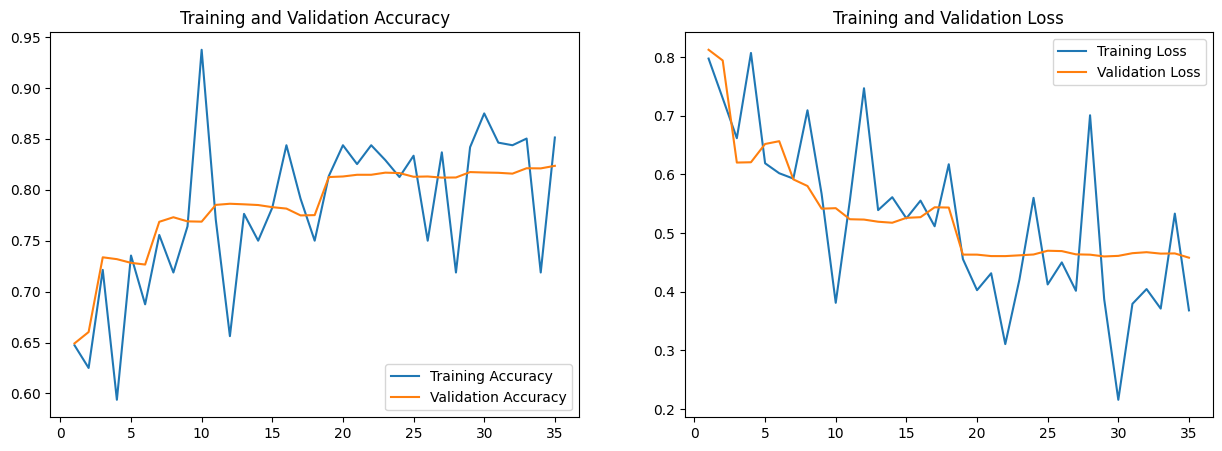

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# 2. Plot Accuracy
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# 3. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# 4. Save the graph to a file
plt.savefig('training_history_graph.png')
plt.show()

Found 7178 images belonging to 3 classes.
Generating predictions... (this may take a moment)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step


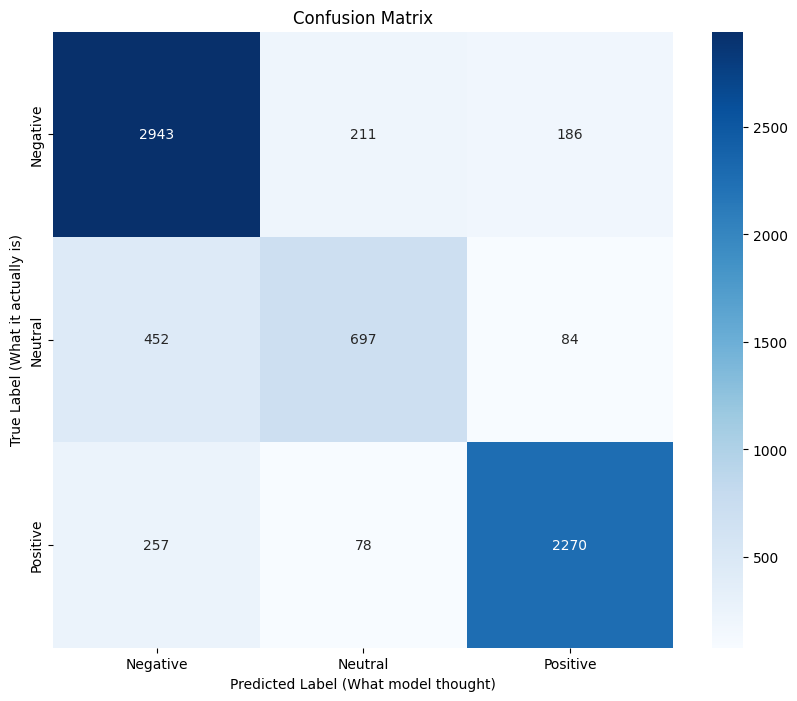


=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.81      0.88      0.84      3340
     Neutral       0.71      0.57      0.63      1233
    Positive       0.89      0.87      0.88      2605

    accuracy                           0.82      7178
   macro avg       0.80      0.77      0.78      7178
weighted avg       0.82      0.82      0.82      7178



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Re-create the validation generator with shuffle=False
# (Crucial for aligning predictions with correct labels)
validation_generator_eval = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # <--- IMPORTANT!
)

# 2. Generate Predictions
print("Generating predictions... (this may take a moment)")
Y_pred = model.predict(validation_generator_eval, validation_generator_eval.samples // batch_size + 1)
y_pred = np.argmax(Y_pred, axis=1)

# 3. Get True Labels
# We take only as many labels as we have predictions (handles potential batch size rounding)
y_true = validation_generator_eval.classes[:len(y_pred)]

# 4. Create the Confusion Matrix
class_labels = list(validation_generator_eval.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

# 5. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.ylabel('True Label (What it actually is)')
plt.xlabel('Predicted Label (What model thought)')
plt.show()

# 6. Print Classification Report (Precision, Recall, F1-Score)
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))